# 11. Policy regimes, value decomposition, and support sensitivity

This notebook explains **where** the terminally corrected dynamic advantage comes from.

It produces:

- funding-capacity policy-regime diagnostics;
- best-versus-second-best schedule gaps;
- exact product- and week-level VDO accounting;
- a dynamic-versus-myopic disagreement taxonomy;
- a matched master-grid support sensitivity over stricter observation thresholds.

## 1. Imports and corrected-policy artifact

In [15]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        root
        for root in [CURRENT_DIR, CURRENT_DIR.parent]
        if (root / "data" / "processed").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from the "
        "repository root or the notebooks directory."
    )

for import_directory in [
    PROJECT_ROOT / "src",
    PROJECT_ROOT,
    CURRENT_DIR,
]:
    if import_directory.is_dir() and str(import_directory) not in sys.path:
        sys.path.insert(0, str(import_directory))

from corrected_promotion_analysis import (
    PlanningSpec,
    SupportSpec,
    build_schedule_system,
    build_supported_action_sets,
    load_pickle,
    run_policy_grid,
    save_pickle,
    schedule_input_fingerprint,
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"

for directory in [PROCESSED_DIR, TABLE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CORRECTED_ARTIFACT_PATH = (
    PROCESSED_DIR
    / "corrected_policy_optimization_artifact.pkl"
)

if not CORRECTED_ARTIFACT_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {CORRECTED_ARTIFACT_PATH}. Run notebook 10 first."
    )

artifact = load_pickle(
    CORRECTED_ARTIFACT_PATH
)

policy_results = (
    artifact["policy_results"]
    .copy()
    .sort_values(["capacity", "alpha"])
    .reset_index(drop=True)
)
product_decomposition = (
    artifact["product_decomposition"]
    .copy()
)
weekly_decomposition = (
    artifact["weekly_decomposition"]
    .copy()
)
schedules = artifact["schedules"]

MAIN_ALPHA = float(
    artifact["main_alpha"]
)
SELECTED_WASHOUT = int(
    artifact["selected_washout"]
)
BASELINE_SUPPORT = (
    artifact["baseline_support"]
)

print("Selected washout:", SELECTED_WASHOUT)
print("Main alpha:", MAIN_ALPHA)
print("Policy rows:", len(policy_results))

Selected washout: 12
Main alpha: 2.24
Policy rows: 152


## 2. Locate policy boundaries

In [16]:
policy_regimes = (
    policy_results.copy()
)

for signature_column in [
    "dynamic_schedule_signature",
    "myopic_schedule_signature",
    "dynamic_active_set",
    "myopic_active_set",
]:
    policy_regimes[
        f"{signature_column}_previous"
    ] = (
        policy_regimes.groupby(
            "capacity",
            observed=True,
        )[
            signature_column
        ].shift()
    )

policy_regimes[
    "dynamic_schedule_change"
] = (
    policy_regimes[
        "dynamic_schedule_signature"
    ]
    != policy_regimes[
        "dynamic_schedule_signature_previous"
    ]
)
policy_regimes[
    "myopic_schedule_change"
] = (
    policy_regimes[
        "myopic_schedule_signature"
    ]
    != policy_regimes[
        "myopic_schedule_signature_previous"
    ]
)
policy_regimes[
    "dynamic_active_set_change"
] = (
    policy_regimes[
        "dynamic_active_set"
    ]
    != policy_regimes[
        "dynamic_active_set_previous"
    ]
)
policy_regimes[
    "myopic_active_set_change"
] = (
    policy_regimes[
        "myopic_active_set"
    ]
    != policy_regimes[
        "myopic_active_set_previous"
    ]
)

first_rows = (
    policy_regimes.groupby(
        "capacity",
        observed=True,
    ).cumcount().eq(0)
)

for column in [
    "dynamic_schedule_change",
    "myopic_schedule_change",
    "dynamic_active_set_change",
    "myopic_active_set_change",
]:
    policy_regimes.loc[
        first_rows,
        column,
    ] = False

policy_regimes[
    "any_policy_boundary"
] = (
    policy_regimes[
        [
            "dynamic_schedule_change",
            "myopic_schedule_change",
            "dynamic_active_set_change",
            "myopic_active_set_change",
        ]
    ].any(axis=1)
)

policy_regimes[
    "relative_best_second_gap"
] = (
    policy_regimes[
        "best_second_gap"
    ]
    / policy_regimes[
        "dynamic_profit"
    ].abs()
)

display(
    policy_regimes.loc[
        policy_regimes[
            "any_policy_boundary"
        ]
    ][
        [
            "alpha",
            "capacity",
            "vdo",
            "vdo_percent",
            "best_second_gap",
            "dynamic_schedule_change",
            "myopic_schedule_change",
            "dynamic_active_set_change",
            "myopic_active_set_change",
        ]
    ].head(40)
)

,alpha,capacity,vdo,vdo_percent,best_second_gap,dynamic_schedule_change,myopic_schedule_change,dynamic_active_set_change,myopic_active_set_change
4,1.60,1,0.391590,1.185600e-02,0.002817,True,False,True,False
5,1.65,1,2.472651,7.488426e-02,0.183538,True,True,True,True
6,1.70,1,0.705936,2.127582e-02,0.039932,True,True,False,False
8,1.80,1,1.715451,5.120751e-02,0.035263,True,False,False,False
9,1.85,1,17.594324,5.251044e-01,0.072861,False,True,False,True
10,1.90,1,4.414056,1.305807e-01,0.110458,False,True,False,False
11,1.95,1,1.197725,3.511692e-02,0.069280,True,False,True,False
17,2.24,1,6.521222,1.820337e-01,0.227885,True,True,True,True
18,2.25,1,7.587671,2.114888e-01,0.216779,False,True,False,True
19,2.30,1,3.779273,1.042804e-01,0.115792,True,False,False,False


In [17]:
top_vdo_by_capacity = (
    policy_regimes.loc[
        policy_regimes.groupby(
            "capacity",
            observed=True,
        )[
            "vdo"
        ].idxmax()
    ][
        [
            "capacity",
            "alpha",
            "vdo",
            "vdo_percent",
            "best_second_gap",
            "action_disagreements",
            "status_disagreements",
            "depth_disagreements",
            "timing_shift_products",
        ]
    ]
    .sort_values("capacity")
    .reset_index(drop=True)
)

display(top_vdo_by_capacity)

,capacity,alpha,vdo,vdo_percent,best_second_gap,action_disagreements,status_disagreements,depth_disagreements,timing_shift_products
0,1,1.85,17.594324,0.525104,0.072861,16,16,0,2
1,2,2.55,48.262393,1.270924,0.565451,36,36,0,4
2,3,2.85,53.171980,1.281556,0.024202,54,54,0,7
3,8,3.20,81.826378,1.756463,0.006156,54,54,0,8


## 3. Main policy-regime figure

C:\Users\janza\AppData\Local\Temp\ipykernel_25264\623092737.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


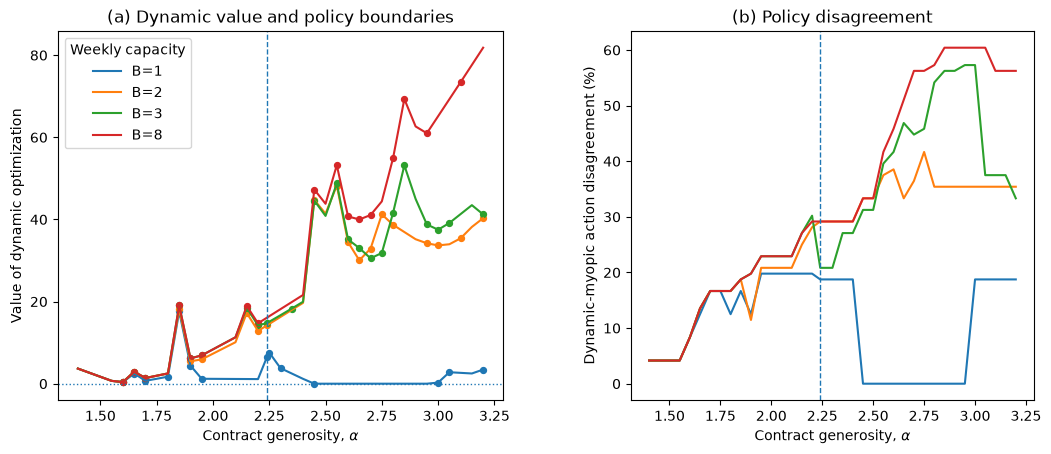

In [18]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12.6, 4.8),
    gridspec_kw={
        "width_ratios": [1.05, 0.95],
        "wspace": 0.30,
    },
)

for capacity, group in (
    policy_regimes.groupby(
        "capacity",
        observed=True,
    )
):
    axes[0].plot(
        group["alpha"],
        group["vdo"],
        label=f"B={capacity}",
    )

    boundary_rows = group.loc[
        group["any_policy_boundary"]
    ]
    axes[0].scatter(
        boundary_rows["alpha"],
        boundary_rows["vdo"],
        s=18,
    )

axes[0].axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)
axes[0].axvline(
    MAIN_ALPHA,
    linestyle="--",
    linewidth=1.0,
)
axes[0].set_xlabel(
    r"Contract generosity, $\alpha$"
)
axes[0].set_ylabel(
    "Value of dynamic optimization"
)
axes[0].set_title(
    "(a) Dynamic value and policy boundaries"
)
axes[0].legend(
    title="Weekly capacity"
)

for capacity, group in (
    policy_regimes.groupby(
        "capacity",
        observed=True,
    )
):
    axes[1].plot(
        group["alpha"],
        100.0 * group["disagreement_rate"],
        label=f"B={capacity}",
    )

axes[1].axvline(
    MAIN_ALPHA,
    linestyle="--",
    linewidth=1.0,
)
axes[1].set_xlabel(
    r"Contract generosity, $\alpha$"
)
axes[1].set_ylabel(
    "Dynamic-myopic action disagreement (%)"
)
axes[1].set_title(
    "(b) Policy disagreement"
)

fig.tight_layout()

POLICY_REGIME_FIGURE_PNG = (
    FIGURE_DIR
    / "paper_policy_regimes_and_disagreement.png"
)
POLICY_REGIME_FIGURE_PDF = (
    FIGURE_DIR
    / "paper_policy_regimes_and_disagreement.pdf"
)

fig.savefig(
    POLICY_REGIME_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    POLICY_REGIME_FIGURE_PDF,
    bbox_inches="tight",
)

plt.show()

Dots in Panel (a) mark funding values at which at least one dynamic or myopic schedule or active set changes relative to the preceding grid point. They should be interpreted as discrete policy boundaries, not statistical significance markers.

## 4. Exact product and week decomposition

In [19]:
MAIN_CAPACITY = 2

main_alpha_available = float(
    policy_results.loc[
        policy_results["capacity"].eq(
            MAIN_CAPACITY
        ),
        "alpha",
    ].iloc[
        np.argmin(
            np.abs(
                policy_results.loc[
                    policy_results[
                        "capacity"
                    ].eq(
                        MAIN_CAPACITY
                    ),
                    "alpha",
                ].to_numpy()
                - MAIN_ALPHA
            )
        )
    ]
)

boundary_row = (
    policy_results.loc[
        policy_results[
            "capacity"
        ].eq(
            MAIN_CAPACITY
        )
    ]
    .sort_values(
        "vdo",
        ascending=False,
    )
    .iloc[0]
)
BOUNDARY_ALPHA = float(
    boundary_row["alpha"]
)

DECOMPOSITION_ALPHAS = sorted(
    {
        round(
            main_alpha_available,
            8,
        ),
        round(
            BOUNDARY_ALPHA,
            8,
        ),
    }
)

print(
    "Decomposition alphas:",
    DECOMPOSITION_ALPHAS,
)

Decomposition alphas: [2.24, 2.55]


In [20]:
selected_product_decomposition = (
    product_decomposition.loc[
        product_decomposition[
            "capacity"
        ].eq(
            MAIN_CAPACITY
        )
        & product_decomposition[
            "alpha"
        ].round(8).isin(
            DECOMPOSITION_ALPHAS
        )
    ]
    .copy()
)

selected_weekly_decomposition = (
    weekly_decomposition.loc[
        weekly_decomposition[
            "capacity"
        ].eq(
            MAIN_CAPACITY
        )
        & weekly_decomposition[
            "alpha"
        ].round(8).isin(
            DECOMPOSITION_ALPHAS
        )
    ]
    .copy()
)

product_accounting_check = (
    selected_product_decomposition.groupby(
        "alpha",
        observed=True,
    )[
        "vdo_contribution"
    ].sum()
)

weekly_accounting_check = (
    selected_weekly_decomposition.groupby(
        "alpha",
        observed=True,
    )[
        "vdo_contribution"
    ].sum()
)

display(
    pd.concat(
        [
            product_accounting_check.rename(
                "product_sum"
            ),
            weekly_accounting_check.rename(
                "weekly_sum"
            ),
        ],
        axis=1,
    )
)

,product_sum,weekly_sum
alpha,,
2.24,14.213812,14.213812
2.55,48.262393,48.262393


In [21]:
product_rankings = (
    selected_product_decomposition.sort_values(
        [
            "alpha",
            "vdo_contribution",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

display(
    product_rankings[
        [
            "alpha",
            "upc",
            "dynamic_profit",
            "myopic_profit",
            "vdo_contribution",
        ]
    ]
)

washout_attribution = (
    selected_weekly_decomposition.groupby(
        [
            "alpha",
            "decision_week",
        ],
        observed=True,
    )[
        "vdo_contribution"
    ]
    .sum()
    .rename(
        "vdo_contribution"
    )
    .reset_index()
)

display(washout_attribution)

,alpha,upc,dynamic_profit,myopic_profit,vdo_contribution
440,2.24,1600066510,596.235989,588.566394,7.669595
444,2.24,3800000120,497.689264,491.010642,6.678622
445,2.24,3800000127,324.491004,324.279803,0.211201
441,2.24,1600066590,531.971993,531.971993,0.000000
442,2.24,1600066610,593.857405,593.857405,0.000000
446,2.24,3800001520,421.807254,421.807254,0.000000
447,2.24,3800001611,420.799897,420.799897,0.000000
443,2.24,3800000110,216.426562,216.772167,-0.345606
503,2.55,3800001611,420.799897,407.531763,13.268134
496,2.55,1600066510,685.898766,672.841676,13.057089


,alpha,decision_week,vdo_contribution
0,2.24,False,-3.248314
1,2.24,True,17.462126
2,2.55,False,10.815603
3,2.55,True,37.446790


C:\Users\janza\AppData\Local\Temp\ipykernel_25264\663344454.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


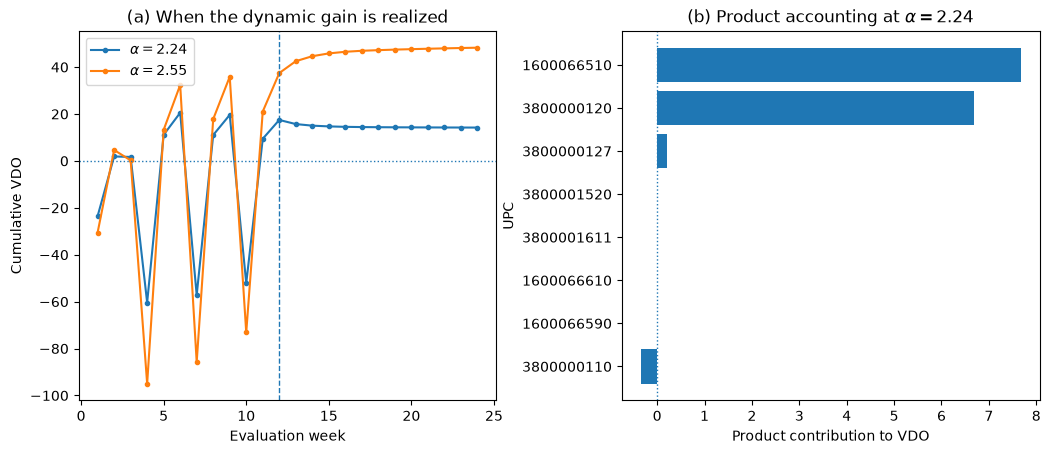

In [22]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12.4, 4.8),
    gridspec_kw={
        "width_ratios": [1.0, 1.0],
        "wspace": 0.30,
    },
)

for alpha, group in (
    selected_weekly_decomposition.groupby(
        "alpha",
        observed=True,
    )
):
    axes[0].plot(
        group["week"],
        group["cumulative_vdo"],
        marker="o",
        markersize=3,
        label=rf"$\alpha={alpha:.2f}$",
    )

axes[0].axvline(
    artifact[
        "schedule_system"
    ][
        "planning"
    ].decision_horizon,
    linestyle="--",
    linewidth=1.0,
)
axes[0].axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)
axes[0].set_xlabel(
    "Evaluation week"
)
axes[0].set_ylabel(
    "Cumulative VDO"
)
axes[0].set_title(
    "(a) When the dynamic gain is realized"
)
axes[0].legend()

main_product = (
    selected_product_decomposition.loc[
        np.isclose(
            selected_product_decomposition[
                "alpha"
            ],
            main_alpha_available,
        )
    ]
    .sort_values(
        "vdo_contribution"
    )
)

axes[1].barh(
    main_product["upc"].astype(str),
    main_product["vdo_contribution"],
)
axes[1].axvline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)
axes[1].set_xlabel(
    "Product contribution to VDO"
)
axes[1].set_ylabel(
    "UPC"
)
axes[1].set_title(
    rf"(b) Product accounting at $\alpha={main_alpha_available:.2f}$"
)

fig.tight_layout()

DECOMPOSITION_FIGURE_PNG = (
    FIGURE_DIR
    / "policy_vdo_decomposition.png"
)
DECOMPOSITION_FIGURE_PDF = (
    FIGURE_DIR
    / "policy_vdo_decomposition.pdf"
)

fig.savefig(
    DECOMPOSITION_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    DECOMPOSITION_FIGURE_PDF,
    bbox_inches="tight",
)

plt.show()

The product and week decompositions are additive accounting identities:
\[
\operatorname{VDO}
=
\sum_i\left[V_i(\pi^D)-V_i(\pi^M)\right]
=
\sum_t\left[V_t(\pi^D)-V_t(\pi^M)\right].
\]
Because products interact through the weekly capacity constraint, these contributions should not be interpreted as independent causal treatment effects.

## 5. Largest adjacent policy switches

In [23]:
def changed_products(
    previous_schedule: dict[str, np.ndarray],
    current_schedule: dict[str, np.ndarray],
) -> tuple[list[str], int]:
    products = sorted(
        set(previous_schedule)
        | set(current_schedule)
    )

    changed = []
    changed_cells = 0

    for upc in products:
        previous = np.asarray(
            previous_schedule[upc],
            dtype=float,
        )
        current = np.asarray(
            current_schedule[upc],
            dtype=float,
        )

        differences = ~np.isclose(
            previous,
            current,
        )

        if differences.any():
            changed.append(upc)
            changed_cells += int(
                differences.sum()
            )

    return changed, changed_cells


switch_rows = []

for capacity, group in (
    policy_results.groupby(
        "capacity",
        observed=True,
    )
):
    group = group.sort_values(
        "alpha"
    )

    previous_row = None

    for row in group.itertuples(
        index=False
    ):
        current_key = (
            round(
                float(row.alpha),
                8,
            ),
            int(capacity),
        )

        if previous_row is not None:
            previous_key = (
                round(
                    float(
                        previous_row.alpha
                    ),
                    8,
                ),
                int(capacity),
            )

            dynamic_changed, dynamic_cells = changed_products(
                schedules[
                    previous_key
                ][
                    "dynamic"
                ],
                schedules[
                    current_key
                ][
                    "dynamic"
                ],
            )
            myopic_changed, myopic_cells = changed_products(
                schedules[
                    previous_key
                ][
                    "myopic"
                ],
                schedules[
                    current_key
                ][
                    "myopic"
                ],
            )

            if (
                dynamic_cells > 0
                or myopic_cells > 0
            ):
                switch_rows.append(
                    {
                        "capacity": (
                            capacity
                        ),
                        "alpha_previous": (
                            previous_row.alpha
                        ),
                        "alpha_current": (
                            row.alpha
                        ),
                        "vdo_previous": (
                            previous_row.vdo
                        ),
                        "vdo_current": (
                            row.vdo
                        ),
                        "vdo_change": (
                            row.vdo
                            - previous_row.vdo
                        ),
                        "dynamic_changed_products": (
                            "|".join(
                                dynamic_changed
                            )
                        ),
                        "dynamic_changed_cells": (
                            dynamic_cells
                        ),
                        "myopic_changed_products": (
                            "|".join(
                                myopic_changed
                            )
                        ),
                        "myopic_changed_cells": (
                            myopic_cells
                        ),
                    }
                )

        previous_row = row

policy_switches = (
    pd.DataFrame(
        switch_rows
    )
    .sort_values(
        "vdo_change",
        key=lambda values: (
            values.abs()
        ),
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    policy_switches.head(20)
)

,capacity,alpha_previous,alpha_current,vdo_previous,vdo_current,vdo_change,dynamic_changed_products,dynamic_changed_cells,myopic_changed_products,myopic_changed_cells
0,8,2.40,2.45,21.607255,47.284156,25.676901,,0,3800001611,4
1,2,2.40,2.45,19.679327,44.759412,25.080085,,0,3800001611,4
2,3,2.40,2.45,19.951465,44.600518,24.649053,,0,3800001611,4
3,3,1.80,1.85,2.501644,19.058565,16.556921,3800000120,2,1600066510,4
4,8,1.80,1.85,2.501644,19.058565,16.556921,3800000120,2,1600066510,4
5,1,1.80,1.85,1.715451,17.594324,15.878873,,0,1600066510,4
6,2,1.80,1.85,2.501644,18.166785,15.665141,3800000120,2,1600066510,4
7,8,2.80,2.85,54.962029,69.334209,14.372180,3800001520,3,3800001520,4
8,2,2.55,2.60,48.262393,34.468003,-13.794390,1600066590,1,,0
9,3,2.55,2.60,48.775605,35.132313,-13.643293,1600066590,4,,0


## 6. Matched-grid support sensitivity

In [24]:
SUPPORT_OBSERVATION_THRESHOLDS = (
    10,
    15,
    25,
    30,
)
SUPPORT_CAPACITY = 2

# Evaluate the baseline funding point and the largest-VDO boundary at B=2.
SUPPORT_ALPHA_VALUES = sorted(
    {
        round(
            main_alpha_available,
            8,
        ),
        round(
            BOUNDARY_ALPHA,
            8,
        ),
    }
)

print(
    "Support sensitivity alphas:",
    SUPPORT_ALPHA_VALUES,
)

Support sensitivity alphas: [2.24, 2.55]


In [25]:
support_sensitivity_runs = []

for minimum_observations in (
    SUPPORT_OBSERVATION_THRESHOLDS
):
    support_spec = replace(
        BASELINE_SUPPORT,
        minimum_observations=(
            minimum_observations
        ),
    )

    threshold_action_sets = (
        build_supported_action_sets(
            support_table=(
                artifact[
                    "support_table"
                ]
            ),
            products=(
                artifact[
                    "products"
                ]
            ),
            support_spec=(
                support_spec
            ),
        )
    )

    action_count = sum(
        len(values) - 1
        for values in (
            threshold_action_sets.values()
        )
    )
    products_with_action = sum(
        len(values) > 1
        for values in (
            threshold_action_sets.values()
        )
    )

    baseline_planning = (
        artifact[
            "schedule_system"
        ][
            "planning"
        ]
    )

    expected_fingerprint = (
        schedule_input_fingerprint(
            draws_by_product=(
                artifact[
                    "draws_by_product"
                ]
            ),
            weekly_profiles=(
                artifact[
                    "weekly_profiles"
                ]
            ),
            action_sets=(
                threshold_action_sets
            ),
            planning=(
                baseline_planning
            ),
            alpha_grid=(
                SUPPORT_ALPHA_VALUES
            ),
        )
    )

    cache_path = (
        PROCESSED_DIR
        / (
            "corrected_support_schedule_system_"
            f"n{minimum_observations}_"
            f"w{SELECTED_WASHOUT}.pkl"
        )
    )

    cache_is_current = False

    if cache_path.is_file():
        cached_system = (
            load_pickle(
                cache_path
            )
        )
        cache_is_current = (
            cached_system.get(
                "input_fingerprint"
            )
            == expected_fingerprint
        )

    if cache_is_current:
        threshold_schedule_system = (
            cached_system
        )

    else:
        threshold_schedule_system = (
            build_schedule_system(
                draws_by_product=(
                    artifact[
                        "draws_by_product"
                    ]
                ),
                weekly_profiles=(
                    artifact[
                        "weekly_profiles"
                    ]
                ),
                action_sets=(
                    threshold_action_sets
                ),
                planning=(
                    baseline_planning
                ),
                alpha_grid=(
                    SUPPORT_ALPHA_VALUES
                ),
                batch_size=256,
            )
        )

        save_pickle(
            threshold_schedule_system,
            cache_path,
        )

    threshold_run = run_policy_grid(
        schedule_system=(
            threshold_schedule_system
        ),
        draws_by_product=(
            artifact[
                "draws_by_product"
            ]
        ),
        weekly_profiles=(
            artifact[
                "weekly_profiles"
            ]
        ),
        action_sets=(
            threshold_action_sets
        ),
        support_table=(
            artifact[
                "support_table"
            ]
        ),
        alpha_values=(
            SUPPORT_ALPHA_VALUES
        ),
        capacities=[
            SUPPORT_CAPACITY
        ],
        compute_second_best=True,
    )

    support_sensitivity_runs.append(
        {
            "support_spec": (
                support_spec
            ),
            "action_sets": (
                threshold_action_sets
            ),
            "run": (
                threshold_run
            ),
            "retained_positive_actions": (
                action_count
            ),
            "products_with_positive_action": (
                products_with_action
            ),
        }
    )

support_sensitivity = pd.concat(
    [
        item[
            "run"
        ][
            "results"
        ].assign(
            minimum_observations=(
                item[
                    "support_spec"
                ].minimum_observations
            ),
            retained_positive_actions=(
                item[
                    "retained_positive_actions"
                ]
            ),
            products_with_positive_action=(
                item[
                    "products_with_positive_action"
                ]
            ),
        )
        for item in (
            support_sensitivity_runs
        )
    ],
    ignore_index=True,
).sort_values(
    [
        "alpha",
        "minimum_observations",
    ]
)

display(
    support_sensitivity[
        [
            "alpha",
            "minimum_observations",
            "dynamic_profit",
            "myopic_profit",
            "vdo",
            "vdo_percent",
            "retained_positive_actions",
            "products_with_positive_action",
            "dynamic_active_products",
            "minimum_chosen_support",
            "minimum_chosen_panels",
        ]
    ]
)

,alpha,minimum_observations,dynamic_profit,myopic_profit,vdo,vdo_percent,retained_positive_actions,products_with_positive_action,dynamic_active_products,minimum_chosen_support,minimum_chosen_panels
0,2.24,10,3396.380262,3391.518277,4.861985,0.143357,23,8,3,34.0,12.0
2,2.24,15,3396.380262,3391.518277,4.861985,0.143357,23,8,3,34.0,12.0
4,2.24,25,3396.380262,3391.518277,4.861985,0.143357,22,8,3,34.0,12.0
6,2.24,30,3396.380262,3391.518277,4.861985,0.143357,22,8,3,34.0,12.0
1,2.55,10,3464.295378,3437.657449,26.637929,0.774886,23,8,4,34.0,9.0
3,2.55,15,3464.295378,3437.657449,26.637929,0.774886,23,8,4,34.0,9.0
5,2.55,25,3464.295378,3445.793276,18.502103,0.536948,22,8,4,34.0,9.0
7,2.55,30,3464.295378,3445.793276,18.502103,0.536948,22,8,4,34.0,9.0


C:\Users\janza\AppData\Local\Temp\ipykernel_25264\744587828.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


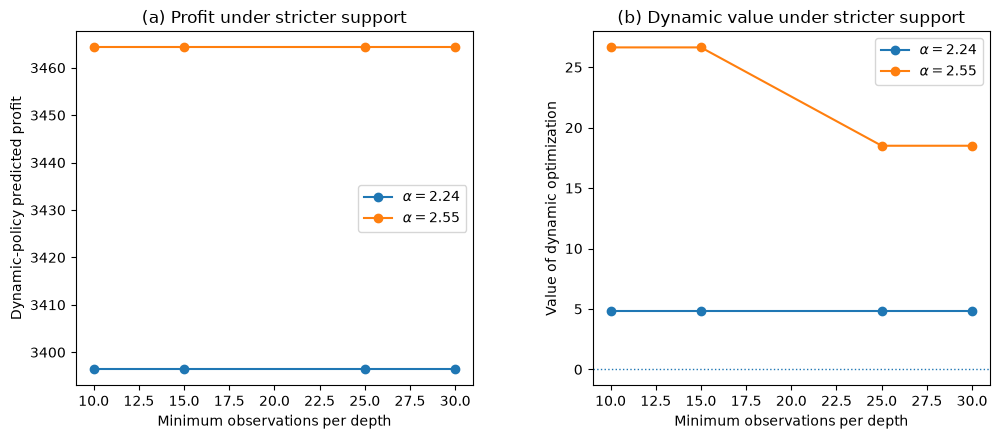

In [26]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(11.8, 4.6),
    gridspec_kw={
        "wspace": 0.30,
    },
)

for alpha, group in (
    support_sensitivity.groupby(
        "alpha",
        observed=True,
    )
):
    axes[0].plot(
        group[
            "minimum_observations"
        ],
        group[
            "dynamic_profit"
        ],
        marker="o",
        label=rf"$\alpha={alpha:.2f}$",
    )

    axes[1].plot(
        group[
            "minimum_observations"
        ],
        group[
            "vdo"
        ],
        marker="o",
        label=rf"$\alpha={alpha:.2f}$",
    )

axes[0].set_xlabel(
    "Minimum observations per depth"
)
axes[0].set_ylabel(
    "Dynamic-policy predicted profit"
)
axes[0].set_title(
    "(a) Profit under stricter support"
)
axes[0].legend()

axes[1].axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)
axes[1].set_xlabel(
    "Minimum observations per depth"
)
axes[1].set_ylabel(
    "Value of dynamic optimization"
)
axes[1].set_title(
    "(b) Dynamic value under stricter support"
)
axes[1].legend()

fig.tight_layout()

SUPPORT_FIGURE_PNG = (
    FIGURE_DIR
    / "support_profit_frontier.png"
)
SUPPORT_FIGURE_PDF = (
    FIGURE_DIR
    / "support_profit_frontier.pdf"
)

fig.savefig(
    SUPPORT_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    SUPPORT_FIGURE_PDF,
    bbox_inches="tight",
)

plt.show()

## 7. Save paper-facing diagnostics

In [27]:
POLICY_REGIME_TABLE_PATH = (
    TABLE_DIR
    / "paper_policy_regime_diagnostics.csv"
)
TOP_VDO_TABLE_PATH = (
    TABLE_DIR
    / "paper_top_vdo_by_capacity.csv"
)
PRODUCT_DECOMPOSITION_TABLE_PATH = (
    TABLE_DIR
    / "paper_product_vdo_decomposition.csv"
)
WEEKLY_DECOMPOSITION_TABLE_PATH = (
    TABLE_DIR
    / "paper_weekly_vdo_decomposition.csv"
)
POLICY_SWITCH_TABLE_PATH = (
    TABLE_DIR
    / "paper_policy_boundary_switches.csv"
)
SUPPORT_SENSITIVITY_TABLE_PATH = (
    TABLE_DIR
    / "paper_support_sensitivity.csv"
)
NOTEBOOK_11_ARTIFACT_PATH = (
    PROCESSED_DIR
    / "policy_regimes_and_support_artifact.pkl"
)

policy_regimes.to_csv(
    POLICY_REGIME_TABLE_PATH,
    index=False,
)
top_vdo_by_capacity.to_csv(
    TOP_VDO_TABLE_PATH,
    index=False,
)
selected_product_decomposition.to_csv(
    PRODUCT_DECOMPOSITION_TABLE_PATH,
    index=False,
)
selected_weekly_decomposition.to_csv(
    WEEKLY_DECOMPOSITION_TABLE_PATH,
    index=False,
)
policy_switches.to_csv(
    POLICY_SWITCH_TABLE_PATH,
    index=False,
)
support_sensitivity.to_csv(
    SUPPORT_SENSITIVITY_TABLE_PATH,
    index=False,
)

notebook_11_artifact = {
    "policy_regimes": (
        policy_regimes
    ),
    "top_vdo_by_capacity": (
        top_vdo_by_capacity
    ),
    "decomposition_alphas": (
        DECOMPOSITION_ALPHAS
    ),
    "product_decomposition": (
        selected_product_decomposition
    ),
    "weekly_decomposition": (
        selected_weekly_decomposition
    ),
    "policy_switches": (
        policy_switches
    ),
    "support_sensitivity": (
        support_sensitivity
    ),
}

save_pickle(
    notebook_11_artifact,
    NOTEBOOK_11_ARTIFACT_PATH,
)

print(
    "Saved:",
    NOTEBOOK_11_ARTIFACT_PATH,
)

Saved: C:\Users\janza\price-of-extrapolation\data\processed\policy_regimes_and_support_artifact.pkl


## Interpretation guardrails

- VDO spikes near schedule changes are evidence that the value of foresight is concentrated near discrete policy boundaries.
- A small best--second-best gap indicates schedule fragility; it is not a confidence interval.
- Product and week contributions are exact accounting decompositions, but category-capacity interactions prevent a causal product-by-product interpretation.
- The support sensitivity uses a fixed five-percentage-point master grid. Raising \(N_{\min}\) therefore removes actions from a common grid rather than redefining the bins.
- The baseline \(15/3\) support rule remains a pragmatic design choice unless the sensitivity analysis demonstrates a clear empirical preference.